# Standardizing the shape of spatial datasets before Vitessce

Script that re-shapes the E11 pre-processed AnnData object from STARmap/SPARTseq to become horizontally aligned by slice. 
Also reduces space b/n individual slices in each dataset manually, and exports the dataset. 

**Input:** AnnData Object for Spatial Data 

**Output:** AnnData Object for Spatial Data

In [2]:
import anndata as ad 
import scanpy as sc
import numpy as np
import pandas as pd 
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import os
import copy

from vitessce import (
    VitessceConfig,
    Component as cm,
    CoordinationType as ct,
    AnnDataWrapper,
)
from vitessce.data_utils import (
    optimize_adata,
    VAR_CHUNK_SIZE,
)

warnings.simplefilter(action="ignore", category=Warning)

sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

print("All packages loaded successfully!")

path = "/Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025"
os.chdir(path)
# verify the change
print("New working directory:", os.getcwd())

sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

All packages loaded successfully!
New working directory: /Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025
scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.24.4 scipy==1.9.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 pynndescent==0.5.13


In [2]:
e11_data = ad.read_h5ad("e11_cell_types_spatialclustering.h5ad")

In [3]:
e11_data.obs['library_id'].unique()

['e11_1', 'e11_2', 'e11_3', 'e11_4']
Categories (4, object): ['e11_1', 'e11_2', 'e11_3', 'e11_4']

In [4]:
e11_data

AnnData object with n_obs × n_vars = 30531 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

In [5]:
pd.DataFrame(e11_data.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,30531.000000,30531.000000
mean,9753.540417,2923.204780
std,4861.583959,1317.760188
min,0.000000,0.000000
25%,5223.264147,1907.279344
50%,10483.662744,3017.052851
75%,14074.373271,3868.956721
max,18408.680837,5996.968239


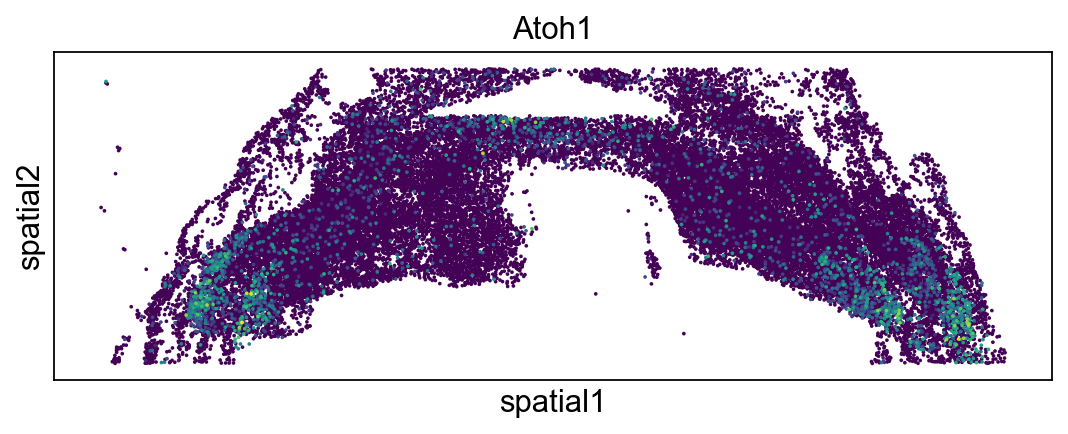

In [6]:
# Plot original spatial 
sc.pl.spatial(e11_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [7]:
# Iterate through each library_id and subset the data
library_subsets = {}
for lib_id in e11_data.obs['library_id'].unique():
    # Create a mask for the current library_id
    mask = e11_data.obs['library_id'] == lib_id
    
    # Subset the AnnData object
    library_subsets[lib_id] = e11_data[mask].copy()
    
    # Extract x and y coordinates for the current library_id
    x_coords = library_subsets[lib_id].obsm['spatial'][:, 0]
    y_coords = library_subsets[lib_id].obsm['spatial'][:, 1]
    
    print(f"Library ID: {lib_id}")
    print(f"X Coordinates: {x_coords[:5]}")  # Print first 5 x-coordinates
    print(f"Y Coordinates: {y_coords[:5]}")  # Print first 5 y-coordinates

Library ID: e11_1
X Coordinates: [ 6952.12383842  6195.18718624 14935.16499023 13948.05470801
 16605.18565305]
Y Coordinates: [1911.58472651 3464.7363006  2680.6385891  2934.59086603 3346.56514834]
Library ID: e11_2
X Coordinates: [ 4939.16636258  5449.70502959 12927.8725703   4925.89972008
 13574.01322245]
Y Coordinates: [1430.62956054  743.31841675  562.05734489 1519.98282227  949.13059852]
Library ID: e11_3
X Coordinates: [ 2256.84206608 13478.21022283 12639.0462575   6448.04786228
  8518.78220072]
Y Coordinates: [3980.92288466 3381.73449136 2053.42238725 1518.78457018 1336.39849646]
Library ID: e11_4
X Coordinates: [ 4338.8231807  12483.00172475  5425.05368167 12834.36871827
  5247.26607839]
Y Coordinates: [2741.17978129 2697.44284337 1813.55558303 2786.73151989 1773.85938206]


Checking original data

In [13]:
e11_2_mask = e11_data.obs['library_id'] == 'e11_2'

In [ ]:
# 'top' represents to all cells in df that are not in e11_2 
e11_2_mask.describe(include='all')

In [ ]:
# Cell count of e11_2
e11_2_mask.sum()

In [16]:
# subset the anndata obj to only include e11_2 slice 
e11_2 = e11_data[e11_2_mask].copy()

In [17]:
# Extract x and y coordinates for the current library_id
x_coords = e11_2.obsm['spatial'][:, 0]
y_coords = e11_2.obsm['spatial'][:, 1]

In [ ]:
e11_2.obsm['spatial'][1]

In [ ]:
print(f"Min x for e11_2: {min(x_coords)}")
print(f"Max x for e11_2: {max(x_coords)}")

print(f"Min y for e11_2: {min(y_coords)}")
print(f"Max y for e11_2: {max(y_coords)}")

In [8]:
e11_1 = e11_data[e11_data.obs['library_id'] == 'e11_1'].copy()
e11_2 = e11_data[e11_data.obs['library_id'] == 'e11_2'].copy()
e11_3 = e11_data[e11_data.obs['library_id'] == 'e11_3'].copy()
e11_4 = e11_data[e11_data.obs['library_id'] == 'e11_4'].copy()

In [9]:
# Extract x and y coordinates for the current library_id
x_coords = e11_1.obsm['spatial'][:, 0]
y_coords = e11_1.obsm['spatial'][:, 1]

print(f"Min x for e11_1: {min(x_coords):.0f}")
print(f"Max x for e11_1: {max(x_coords):.0f}")

print(f"Min y for e11_1: {min(y_coords):.0f}")
print(f"Max y for e11_1: {max(y_coords):.0f}")

Min x for e11_1: 1088
Max x for e11_1: 18409
Min y for e11_1: 1699
Max y for e11_1: 5996


In [10]:
# Extract x and y coordinates for the current library_id
x_coords = e11_2.obsm['spatial'][:, 0]
y_coords = e11_2.obsm['spatial'][:, 1]

print(f"Min x for e11_2: {min(x_coords):.0f}")
print(f"Max x for e11_2: {max(x_coords):.0f}")

print(f"Min y for e11_2: {min(y_coords):.0f}")
print(f"Max y for e11_2: {max(y_coords):.0f}")

Min x for e11_2: 99
Max x for e11_2: 18140
Min y for e11_2: 0
Max y for e11_2: 5997


In [11]:
# Extract x and y coordinates for the current library_id
x_coords = e11_3.obsm['spatial'][:, 0]
y_coords = e11_3.obsm['spatial'][:, 1]

print(f"Min x for e11_3: {min(x_coords):.0f}")
print(f"Max x for e11_3: {max(x_coords):.0f}")

print(f"Min y for e11_3: {min(y_coords):.0f}")
print(f"Max y for e11_3: {max(y_coords):.0f}")

Min x for e11_3: 882
Max x for e11_3: 17171
Min y for e11_3: 998
Max y for e11_3: 5995


In [12]:
# Extract x and y coordinates for the current library_id
x_coords = e11_4.obsm['spatial'][:, 0]
y_coords = e11_4.obsm['spatial'][:, 1]

print(f"Min x for e11_4: {min(x_coords):.0f}")
print(f"Max x for e11_4: {max(x_coords):.0f}")

print(f"Min y for e11_4: {min(y_coords):.0f}")
print(f"Max y for e11_4: {max(y_coords):.0f}")

Min x for e11_4: 0
Max x for e11_4: 16467
Min y for e11_4: 954
Max y for e11_4: 5997


In [13]:
# subtract all coordinates in each Anndata object by min x and y values 
# List of AnnData objects
adatas_list = [e11_1, e11_2, e11_3, e11_4]  # Replace with your actual AnnData objects

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = adata.obsm["spatial"]
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Subtract min_x and min_y from all coordinates
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Verify the adjustment for one dataset
print("Adjusted spatial coordinates for e11_1:")
print(e11_1.obsm["spatial"][:10])

Adjusted spatial coordinates for e11_1:
[[ 5863.88458422   212.20100646]
 [ 5106.94793204  1765.35258055]
 [13846.92573602   981.25486905]
 [12859.81545381  1235.20714598]
 [15516.94639885  1647.18142828]
 [14132.3508349    908.28115571]
 [15366.37033757  1682.73459576]
 [ 5756.0138324    495.77878516]
 [ 3778.14431439  1419.15565678]
 [13664.26294987  1024.92124926]]


In [14]:
pd.DataFrame(e11_4.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,6369.000000,6369.000000
mean,9050.497148,1891.079395
std,4430.189241,1145.573826
min,0.000000,0.000000
25%,4926.346952,844.964350
50%,9552.075977,1954.503900
75%,13027.142486,2710.023248
max,16467.494046,5042.938574


In [15]:
e11_4

AnnData object with n_obs × n_vars = 6369 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

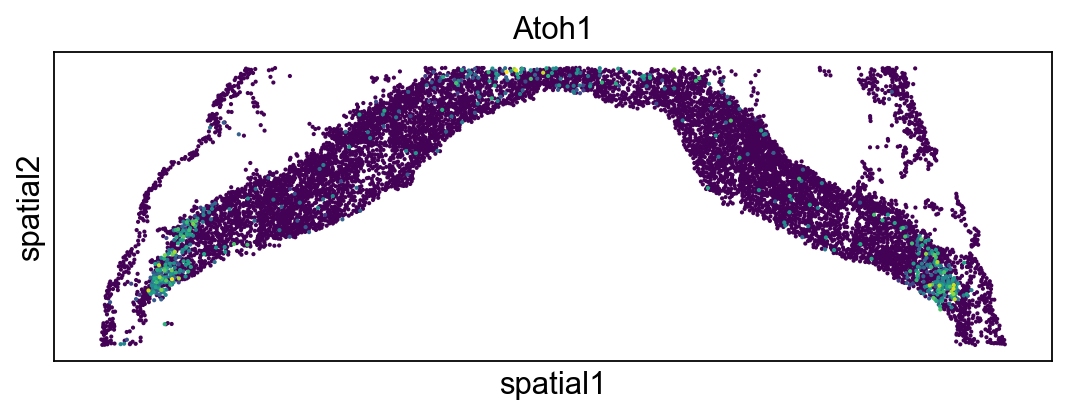

In [16]:
sc.pl.spatial(e11_3, spot_size = 75, color = "Atoh1", colorbar_loc = None)

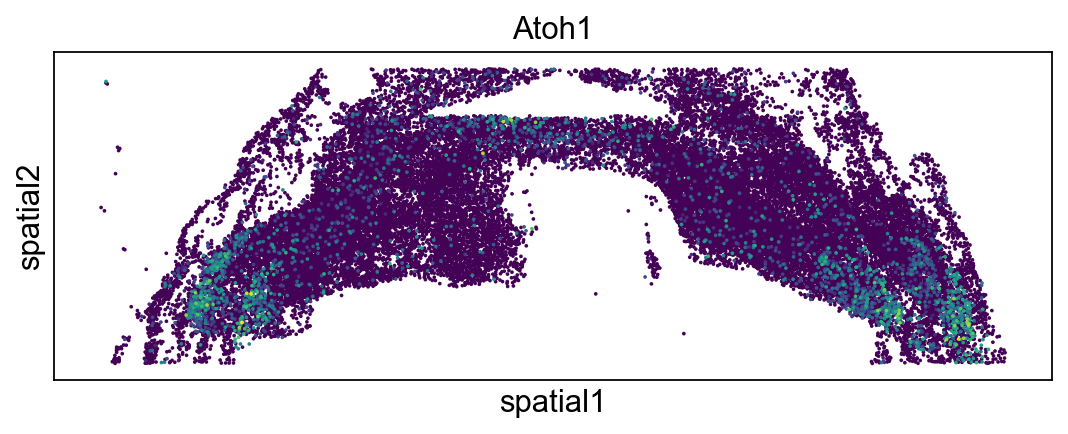

In [17]:
sc.pl.spatial(e11_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [25]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e11_1, e11_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1600 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e11_1_2_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e11_1", "e11_2"])

# Verify the combined AnnData object
print(e11_1_2_combined)
print(e11_1_2_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 16161 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
[[ 5863.88458422   212.20100646]
 [ 5106.94793204  1765.35258055]
 [13846.92573602   981.25486905]
 [12859.81545381  1235.20714598]
 [15516.94639885  1647.18142828]
 [14132.3508349    908.28115571]
 [15366.37033757  1682.73459576]
 [ 5756.0138324    495.77878516]
 [ 3778.14431439  1419.15565678]
 [13664.26294987  1024.92124926]]


In [26]:
16172 + 16152 + 17587 + 16505

66416

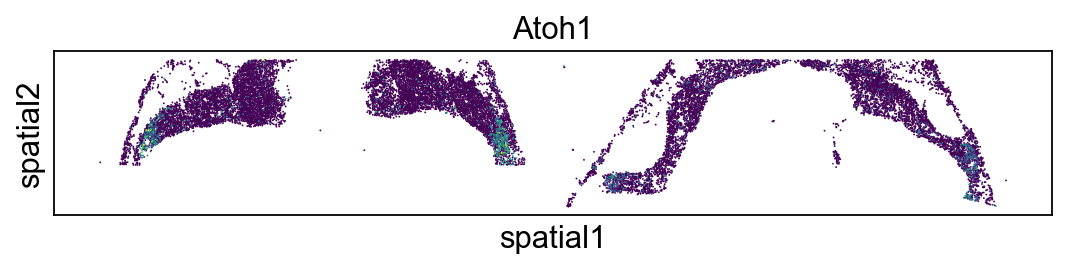

In [27]:
sc.pl.spatial(e11_1_2_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [28]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e11_3, e11_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1600 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e11_3_4_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e11_3", "e11_4"])

# Verify the combined AnnData object
print(e11_3_4_combined)
print(e11_3_4_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 14370 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
[[ 1375.30362936  2983.08131132]
 [12596.67178611  2383.89291801]
 [11757.50782077  1055.5808139 ]
 [ 5566.50942556   520.94299684]
 [ 7637.24376399   338.55692312]
 [ 3334.76628519  2113.09539027]
 [11635.13968124  1048.66874409]
 [11676.09348867  1247.25561633]
 [ 5393.71836903   484.90172385]
 [11383.59009997   986.94522275]]


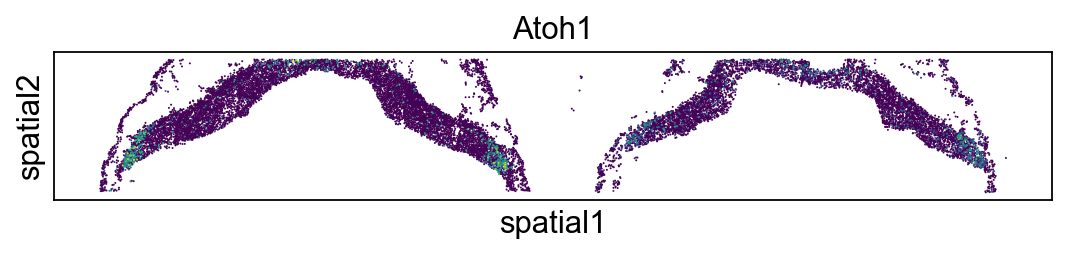

In [29]:
sc.pl.spatial(e11_3_4_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [30]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e11_1_2_combined, e11_3_4_combined]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1600 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e11_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e11_1", "e11_2", "e11_3", "e11_4"])

# Verify the combined AnnData object
print(e11_combined)
print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 30531 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
[[ 5863.88458422   212.20100646]
 [ 5106.94793204  1765.35258055]
 [13846.92573602   981.25486905]
 [12859.81545381  1235.20714598]
 [15516.94639885  1647.18142828]
 [14132.3508349    908.28115571]
 [15366.37033757  1682.73459576]
 [ 5756.0138324    495.77878516]
 [ 3778.14431439  1419.15565678]
 [13664.26294987  1024.92124926]]


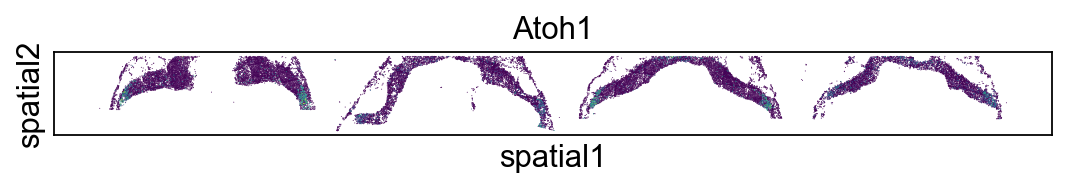

In [31]:
sc.pl.spatial(e11_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [33]:
e11_combined.obsm_keys

<bound method AnnData.obsm_keys of AnnData object with n_obs × n_vars = 30531 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'>

In [104]:
# Get all categories
categories = e11_3.obs['finer_cell_types'].cat.categories
len(categories)

colors = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#FF7F00",  # orange
    "#984EA3",  # purple
    "#F781BF",  # pink
    "#A65628",  # brown
    "#FFFF33",  # yellow
    "#66C2A5",  # teal
    "#FC8D62",  # coral
    "#8DA0CB",  # light blue
    "#E78AC3",  # light pink
    "#ff0081"
][:len(categories)]

# Assign to AnnData
e11_3.uns['finer_cell_types_colors'] = colors

In [177]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    e11_3,
    spot_size=50,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    sort_order=True,
    frameon=False,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/e11_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

In [112]:
os.getcwd()

'/Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025'

In [113]:
e11_combined

AnnData object with n_obs × n_vars = 30531 × 1716
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    uns: 'finer_cell_types_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'

In [114]:
# Rename an observation variable in the AnnData object
e11_combined.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
e11_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e11_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'hybrid_leiden', 'broad_cell_types',
       'cell_types', 'excitatory', 'inhibitory'],
      dtype='object')


In [115]:
import pandas as pd
pd.DataFrame(e11_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,30531.000000,30531.000000
mean,35572.446699,1968.088043
std,21297.577289,1260.811477
min,0.000000,0.000000
25%,15459.409405,947.865193
50%,34883.425079,1863.436770
75%,52562.082201,2751.890701
max,72918.853276,5996.968239


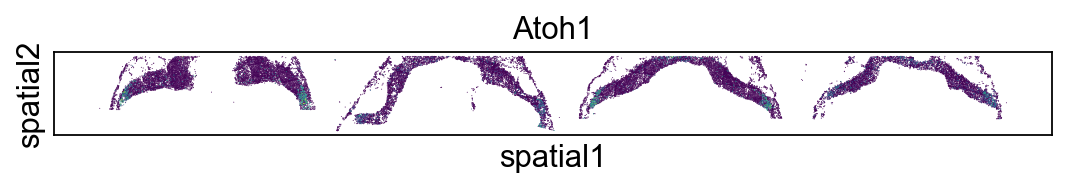

In [116]:
sc.pl.spatial(e11_combined, spot_size=75, colorbar_loc = None, color = "Atoh1")

In [118]:
e11_combined.write("data-for-vitessce/e11_data.h5ad")

Also modify spacing between other Timepoint datasets: 

# E12

In [121]:
os.getcwd()

'/Users/iriskwon/Library/CloudStorage/OneDrive-SharedLibraries-JohnsHopkins/Manjari Anant - Iris/website_data_09_2025'

In [4]:
# Load data 
e12_data = ad.read_h5ad("e12_cell_types_7-31-25.h5ad")

In [5]:
e12_data

AnnData object with n_obs × n_vars = 28187 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
e12_data.obs['library_id'].unique()

['e12_1', 'e12_2']
Categories (2, object): ['e12_1', 'e12_2']

In [7]:
e12_1 = e12_data[e12_data.obs['library_id'] == 'e12_1'].copy()
e12_2 = e12_data[e12_data.obs['library_id'] == 'e12_2'].copy()

In [8]:
e12_2

AnnData object with n_obs × n_vars = 14541 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [134]:
import copy
import anndata as ad

# List of AnnData objects
adatas_list = [e12_1, e12_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1800 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e12_1_2 = ad.concat(adatas_list, join="outer", label="batch", keys=["e12_1", "e12_2"])

# Verify the combined AnnData object
print(e12_1_2)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 28187 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial3d'


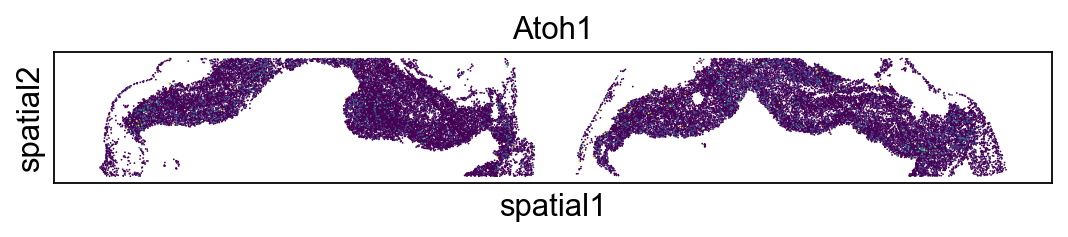

In [135]:
sc.pl.spatial(e12_1_2, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [149]:
# Get all categories
categories = e12_1.obs['finer_cell_types'].cat.categories
len(categories)

17

In [162]:
colors = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#FF7F00",  # orange
    "#984EA3",  # purple
    "#F781BF",  # pink
    "#A65628",  # brown
    "#FFFF33",  # yellow
    "#66C2A5",  # teal
    "#FC8D62",  # coral
    "#8DA0CB",  # light blue
    "#E78AC3",  # light pink
    "#B3DE69",  # lime green
    "#CAB2D6",  # lavender
    "#FDBF6F",  # peach
    "#A6CEE3",  # sky blue
    "#FF69B4",  # hot pink
][:len(categories)]

# Assign to AnnData
e12_1.uns['finer_cell_types_colors'] = colors

In [12]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    e12_2,
    spot_size=65,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    sort_order=True,
    frameon=False,  
    show=False  # important to prevent immediate display
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/e12_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

In [170]:
e12_1_2

AnnData object with n_obs × n_vars = 28187 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial3d'

In [171]:
# Rename an observation variable in the AnnData object
e12_1_2.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
e12_1_2.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e12_1_2.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types',
       'excitatory', 'inhibitory'],
      dtype='object')


In [172]:
e12_1_2.write("data-for-vitessce/e12_data.h5ad")

# E13

In [178]:
e13_data = ad.read_h5ad("e13_cell_types_spatial_clustering.h5ad")

In [179]:
e13_data

AnnData object with n_obs × n_vars = 32511 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'
    varm: 'PCs'

In [180]:
e13_data.obs['library_id'].unique()

['e13_1', 'e13_3', 'e13_4']
Categories (3, object): ['e13_1', 'e13_3', 'e13_4']

In [181]:
e13_1 = e13_data[e13_data.obs['library_id'] == 'e13_1'].copy()
e13_3 = e13_data[e13_data.obs['library_id'] == 'e13_3'].copy()
e13_4 = e13_data[e13_data.obs['library_id'] == 'e13_4'].copy()

In [188]:
# List of AnnData objects
adatas_list = [e13_1, e13_3]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e13_1_3 = ad.concat(adatas_list, join="outer", label="batch", keys=["e13_1", "e13_3"])

# Verify the combined AnnData object
print(e13_1_3)

AnnData object with n_obs × n_vars = 24523 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'


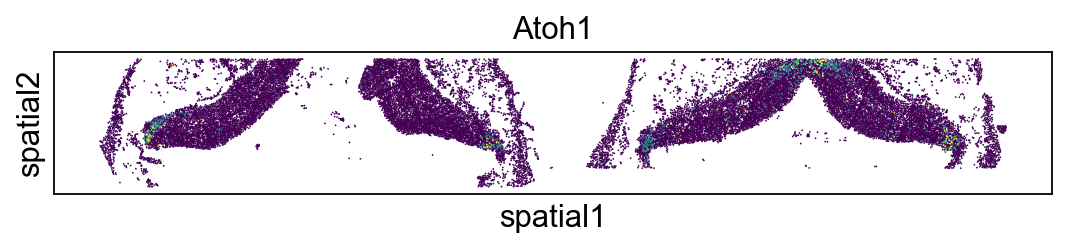

In [189]:
sc.pl.spatial(e13_1_3, spot_size = 75, color = "Atoh1", colorbar_loc = None)

AnnData object with n_obs × n_vars = 32511 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'


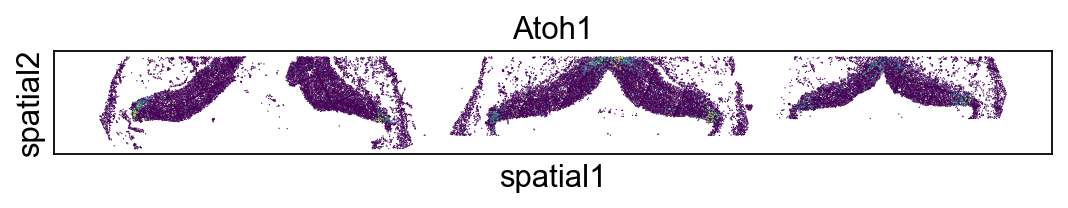

In [190]:
# List of AnnData objects
adatas_list = [e13_1_3, e13_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e13_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e13_1", "e13_3", "e13_4"])

# Verify the combined AnnData object
print(e13_combined)

sc.pl.spatial(e13_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [194]:
# Rename an observation variable in the AnnData object
e13_combined.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
e13_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e13_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'hybrid_leiden', 'broad_cell_types',
       'cell_types', 'excitatory', 'inhibitory'],
      dtype='object')


In [195]:
pd.DataFrame(e13_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,32511.000000,32511.000000
mean,26753.770966,2085.528970
std,15536.571268,1121.738494
min,0.000000,0.000000
25%,13410.455624,1191.122112
50%,27908.325570,2143.839392
75%,38385.971116,2912.906245
max,54134.627302,5497.083974


In [197]:
e13_combined.write("data-for-vitessce/e13_data.h5ad")

In [198]:
# Get all categories
categories = e13_3.obs['finer_cell_types'].cat.categories
len(categories)

21

In [200]:
colors = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#FF7F00",  # orange
    "#984EA3",  # purple
    "#F781BF",  # pink
    "#A65628",  # brown
    "#FFFF33",  # yellow
    "#66C2A5",  # teal
    "#FC8D62",  # coral
    "#8DA0CB",  # light blue
    "#E78AC3",  # light pink
    "#B3DE69",  # lime green
    "#CAB2D6",  # lavender
    "#FDBF6F",  # peach
    "#A6CEE3",  # sky blue
    "#FF69B4",  # hot pink
    "#33A02C",  # dark green
    "#1F78B4",  # deep blue
    "#FFD92F",  # golden yellow
    "#FB9A99",  # soft salmon
][:len(categories)]

e13_3.uns['finer_cell_types_colors'] = colors

In [212]:
e13_3

AnnData object with n_obs × n_vars = 12090 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'cell_types_colors', 'finer_cell_types_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'
    varm: 'PCs'

[]

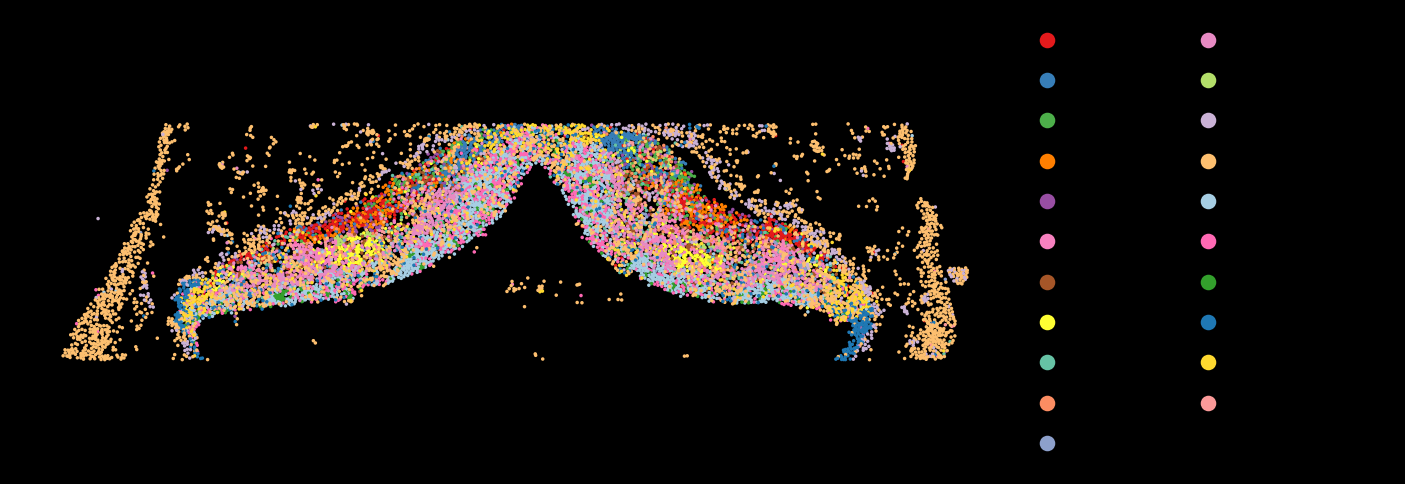

In [326]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    e13_3,
    spot_size=70,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    sort_order=True,
    frameon=False,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
# plt.savefig("figures/e13_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
# plt.close()

# E14 
### Need updated dataset with correct cell type annot!

In [25]:
e14_data = ad.read_h5ad("e14_cell_types_spatial_8-11.h5ad")

In [26]:
e14_data.obs['library_id'].unique()

['e14_1', 'e14_2', 'e14_3']
Categories (3, object): ['e14_1', 'e14_2', 'e14_3']

In [27]:
e14_data.obsm["spatial"][:, 1] = e14_data.obsm["spatial"][:, 1].max() - e14_data.obsm["spatial"][:, 1]

In [29]:
e14_1 = e14_data[e14_data.obs['library_id'] == 'e14_1'].copy()
e14_2 = e14_data[e14_data.obs['library_id'] == 'e14_2'].copy()
e14_3 = e14_data[e14_data.obs['library_id'] == 'e14_3'].copy()

In [30]:
# List of AnnData objects
adatas_list = [e14_1, e14_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e14_1_2 = ad.concat(adatas_list, join="outer", label="batch", keys=["e14_1", "e14_2"])

# Verify the combined AnnData object
print(e14_1_2)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 58223 × 1749
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'finer_cell_types', 'cell_types', 'excitatory', 'inhibitory'
    obsm: 'spatial', 'spatial3d'


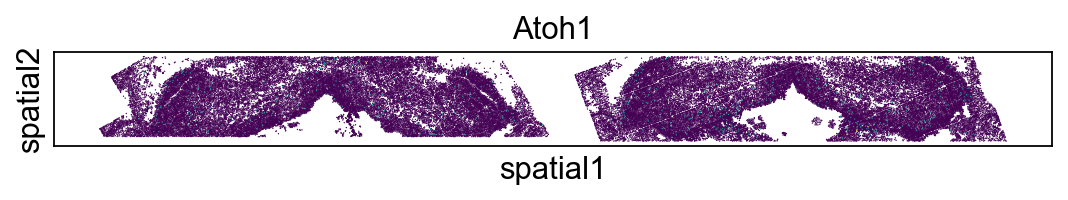

In [31]:
sc.pl.spatial(e14_1_2, spot_size = 75, color = "Atoh1", colorbar_loc = None)

AnnData object with n_obs × n_vars = 90278 × 1749
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'finer_cell_types', 'cell_types', 'excitatory', 'inhibitory'
    obsm: 'spatial', 'spatial3d'


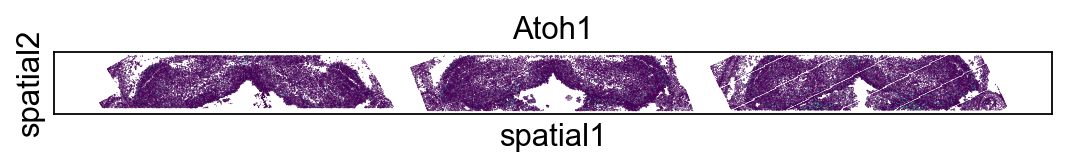

In [32]:
# List of AnnData objects
adatas_list = [e14_1_2, e14_3]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e14_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e14_1", "e14_2", "e14_3"])

# Verify the combined AnnData object
print(e14_combined)

sc.pl.spatial(e14_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

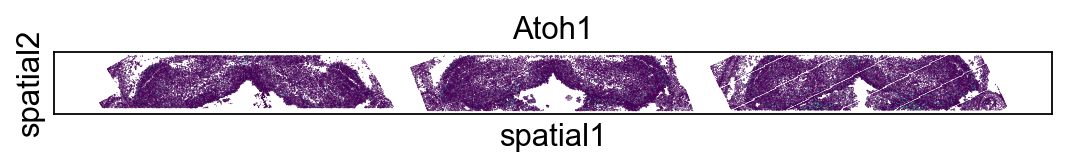

In [33]:
sc.pl.spatial(e14_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [34]:
print(e14_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'finer_cell_types',
       'cell_types', 'excitatory', 'inhibitory'],
      dtype='object')


In [35]:
# Rename an observation variable in the AnnData object
e14_combined.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
e14_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e14_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'cell_types',
       'broad_cell_types', 'excitatory', 'inhibitory'],
      dtype='object')


In [36]:
pd.DataFrame(e14_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,90278.000000,90278.000000
mean,40143.871852,2440.485653
std,22467.068616,1293.307732
min,0.000000,0.000000
25%,19665.985334,1352.642563
50%,41542.570200,2443.793909
75%,60354.845932,3579.701519
max,77802.731871,4749.785237


In [37]:
e14_combined.write("data-for-vitessce/e14_data.h5ad")

In [45]:
e14_2

AnnData object with n_obs × n_vars = 30260 × 1749
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'finer_cell_types', 'cell_types', 'excitatory', 'inhibitory'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'spatial', 'spatial3d'

In [38]:
# Get all categories
categories = e14_1.obs['finer_cell_types'].cat.categories
len(categories)

6

In [50]:
colors = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#FF7F00",  # orange
    "#984EA3",  # purple
    "#F781BF",  # pink
    "#A65628",  # brown
    "#FFFF33",  # yellow
    "#66C2A5",  # teal
    "#FC8D62",  # coral
    "#8DA0CB",  # light blue
    "#E78AC3",  # light pink
    "#B3DE69",  # lime green
    "#CAB2D6",  # lavender
    "#FDBF6F",  # peach
    "#A6CEE3",  # sky blue
    "#FF69B4",  # hot pink
    "#33A02C",  # dark green
    "#1F78B4",  # deep blue
    "#FFD92F",  # golden yellow
    "#FB9A99",  # soft salmon
][:len(categories)]

e14_1.uns['finer_cell_types_colors'] = colors

In [39]:
e14_1

AnnData object with n_obs × n_vars = 27963 × 1749
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'finer_cell_types', 'cell_types', 'excitatory', 'inhibitory'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'spatial', 'spatial3d'

In [53]:
e14_1.obs['finer_cell_types'].value_counts()

finer_cell_types
Other    26991
X          315
IntP       203
Med1       203
Med2       184
Lat         67
Name: count, dtype: int64

In [55]:
# Reorder finer_cell_types in ascending order
e14_1.obs['finer_cell_types'] = e14_1.obs['finer_cell_types'].cat.reorder_categories(
    sorted(e14_1.obs['finer_cell_types'].cat.categories),
    ordered=True
)

# Verify the reordering
print(e14_1.obs['finer_cell_types'].cat.categories)

Index(['IntP', 'Lat', 'Med1', 'Med2', 'Other', 'X'], dtype='object')


In [57]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    e14_1,
    spot_size=75,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    frameon=True,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/e14_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

# E15 (TODO)

In [58]:
# Load data 
e15_data = ad.read_h5ad("e15_cell_types_5-27-2025spatial_8-11.h5ad")

e15_data

AnnData object with n_obs × n_vars = 153433 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

In [59]:
e15_data.obs['library_id'].unique()

['e15_1', 'e15_2', 'e15_3', 'e15_4']
Categories (4, object): ['e15_1', 'e15_2', 'e15_3', 'e15_4']

In [60]:
# Flip the e14_combined dataset along the y-axis
e15_data.obsm["spatial"][:, 1] = e15_data.obsm["spatial"][:, 1].max() - e15_data.obsm["spatial"][:, 1]

In [61]:
e15_1 = e15_data[e15_data.obs['library_id'] == 'e15_1'].copy()
e15_2 = e15_data[e15_data.obs['library_id'] == 'e15_2'].copy()
e15_3 = e15_data[e15_data.obs['library_id'] == 'e15_3'].copy()
e15_4 = e15_data[e15_data.obs['library_id'] == 'e15_4'].copy()

In [62]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e15_1, e15_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e15_12 = ad.concat(adatas_list, join="outer", label="batch", keys=["e15_1", "e15_2"])

# Verify the combined AnnData object
print(e15_12)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 76582 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


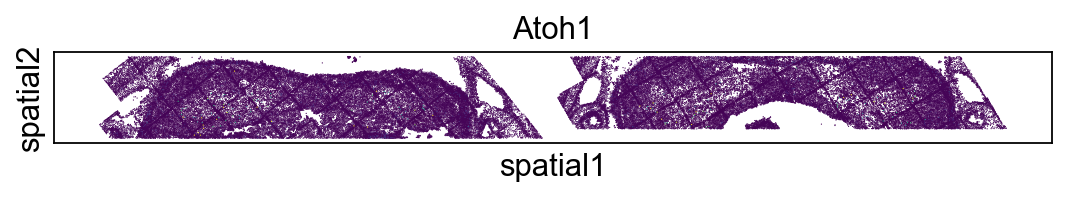

In [63]:
sc.pl.spatial(e15_12, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [64]:
# List of AnnData objects
adatas_list = [e15_3, e15_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e15_34 = ad.concat(adatas_list, join="outer", label="batch", keys=["e15_3", "e15_4"])

# Verify the combined AnnData object
print(e15_34)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 76851 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


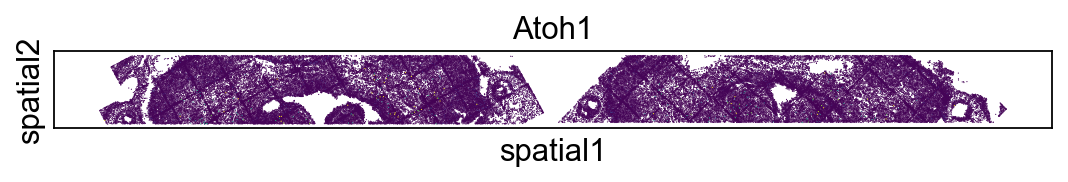

In [65]:
sc.pl.spatial(e15_34, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [66]:
# List of AnnData objects
adatas_list = [e15_12, e15_34]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e15_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e15_1", "e15_2", "e15_3", "e15_4"])

# Verify the combined AnnData object
print(e15_combined)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 153433 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


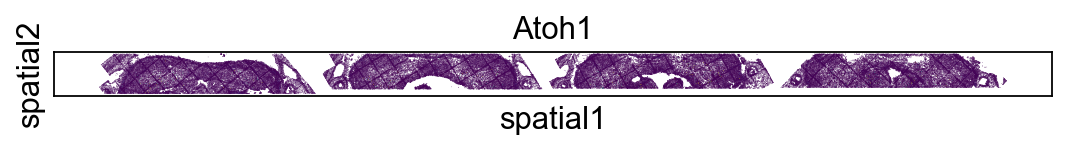

In [67]:
sc.pl.spatial(e15_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [68]:
# Rename an observation variable in the AnnData object
e15_combined.obs.rename(columns={"cell_type": "broad_cell_types"}, inplace=True)
e15_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e15_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'hybrid_leiden', 'broad_cell_types', 'cell_types', 'excitatory',
       'inhibitory'],
      dtype='object')


In [69]:
pd.DataFrame(e15_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,153433.000000,153433.000000
mean,57528.688018,2494.258097
std,34197.123482,1338.169608
min,0.000000,0.000000
25%,24727.546936,1386.752632
50%,59085.480773,2511.464425
75%,84507.636625,3636.549632
max,118030.732042,5198.961394


In [70]:
e15_combined.write("data-for-vitessce/e15_data.h5ad")

In [72]:
e15_3

AnnData object with n_obs × n_vars = 40382 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

In [73]:
# Get all categories (only annotating CNs)
categories = e15_3.obs['finer_cell_types'].cat.categories
len(categories)

6

In [74]:
# Count cells per category
counts = e15_3.obs["finer_cell_types"].value_counts()

# Order categories by ascending cell count (least to most)
ordered_categories = counts.sort_values(ascending=True).index.tolist()


[]

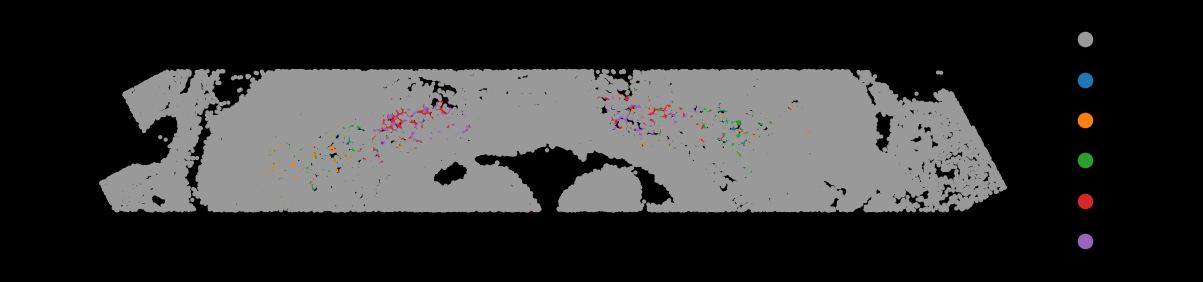

In [78]:
# Put "Other" FIRST so it's drawn first (background)
ordered_categories = ["Other"] + non_other

# Reorder categorical dtype
e15_3.obs["finer_cell_types"] = pd.Categorical(
    e15_3.obs["finer_cell_types"],
    categories=ordered_categories,
    ordered=True
)

# Palette: muted gray for Other, nice colors for real groups
palette = dict(zip(non_other, sns.color_palette("tab10", len(non_other))))
palette["Other"] = (0.6, 0.6, 0.6)  # gray

# Plot
fig, ax = plt.subplots(figsize=(8, 10), facecolor="black")
ax.set_facecolor("black")

sc.pl.spatial(
    e15_3,
    spot_size=135,
    color="finer_cell_types",
    palette=palette,
    colorbar_loc=None,
    ax=ax,
    show=False
)

ax.set_xticks([])
ax.set_yticks([])


In [125]:

# Reorder the categorical dtype
e15_3.obs["finer_cell_types"] = pd.Categorical(
    e15_3.obs["finer_cell_types"],
    categories=ordered_categories,
    ordered=True
)

In [81]:
e15_3

AnnData object with n_obs × n_vars = 40382 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

[]

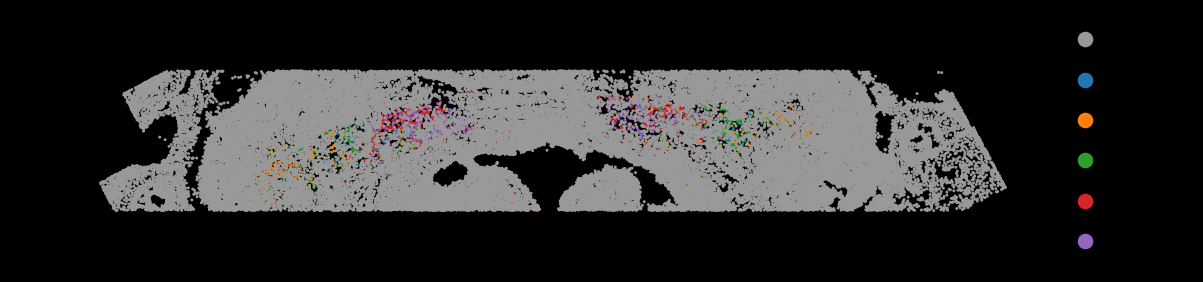

In [ ]:
# Now plot again, legend will follow the new order
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')
ax.set_facecolor('black')

sc.pl.spatial(
    e15_3,
    spot_size=95,
    color="excitatory",
    colorbar_loc=None,
    ax=ax,
    show=False
)

ax.set_xticks([])
ax.set_yticks([])


In [89]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    e15_3,
    spot_size=95,
    color='excitatory',
    colorbar_loc=None,
    ax=ax,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/e15_excitatory.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

# E17 (TODO)

In [87]:
# Load data 
e17_data = ad.read_h5ad("e17_cell_types_spatial_8-11.h5ad")

e17_data

AnnData object with n_obs × n_vars = 87554 × 1748
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'cell_type', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'finer_cell_types_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

In [94]:
# Flip the e14_combined dataset along the y-axis
e17_data.obsm["spatial"][:, 1] = e17_data.obsm["spatial"][:, 1].max() - e17_data.obsm["spatial"][:, 1]

In [95]:
e17_data.obs['library_id'].unique()

['e17_1', 'e17_2', 'e17_3']
Categories (3, object): ['e17_1', 'e17_2', 'e17_3']

In [96]:
e17_1 = e17_data[e17_data.obs['library_id'] == 'e17_1'].copy()
e17_2 = e17_data[e17_data.obs['library_id'] == 'e17_2'].copy()
e17_3 = e17_data[e17_data.obs['library_id'] == 'e17_3'].copy()

In [97]:
# Get all categories
categories = e17_1.obs['finer_cell_types'].cat.categories
len(categories)

14

In [98]:
import copy
import anndata as ad

# List of AnnData objects
adatas_list = [e17_1, e17_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e17_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e17_1", "e17_2"])

# Verify the combined AnnData object
print(e17_combined)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 56320 × 1748
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'cell_type', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


In [99]:
import copy
import anndata as ad

# List of AnnData objects
adatas_list = [e17_combined, e17_3]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e17_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e17_1", "e17_2", "e17_3"])

# Verify the combined AnnData object
print(e17_combined)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 87554 × 1748
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'cell_type', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


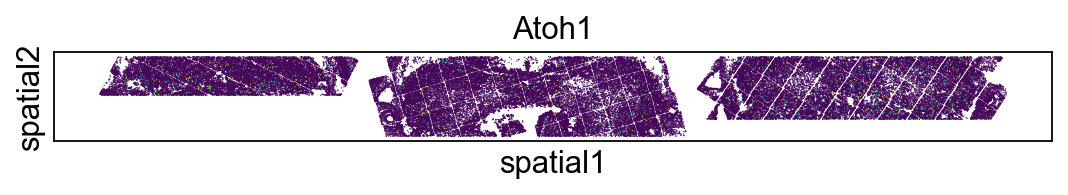

In [100]:
sc.pl.spatial(e17_combined, spot_size = 105, color = "Atoh1", colorbar_loc = None)

In [101]:
pd.DataFrame(e17_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,87554.000000,87554.000000
mean,41943.127205,2865.377373
std,21698.988824,1824.058042
min,0.000000,0.000000
25%,26682.005484,1331.353236
50%,41742.215471,2647.531233
75%,60757.197477,4272.625502
max,79525.702733,6999.963865


In [102]:
# Rename an observation variable in the AnnData object
e17_combined.obs.rename(columns={"cell_type": "broad_cell_types"}, inplace=True)
e17_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e17_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types',
       'broad_cell_types', 'excitatory', 'inhibitory'],
      dtype='object')


In [103]:
e17_combined.write("data-for-vitessce/e17_data.h5ad")

In [123]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    e17_2,
    spot_size=85,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    frameon=False,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/e17_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

# P0 

In [273]:
p0_data = ad.read_h5ad("p0_cell_types_6-21-2025.h5ad")
p0_data

AnnData object with n_obs × n_vars = 241887 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'

In [274]:
p0_data.obs['library_id'].unique()

['p0_1', 'p0_2', 'p0_3', 'p0_4']
Categories (4, object): ['p0_1', 'p0_2', 'p0_3', 'p0_4']

In [275]:
p0_1 = p0_data[p0_data.obs['library_id'] == 'p0_1'].copy()
p0_2 = p0_data[p0_data.obs['library_id'] == 'p0_2'].copy()
p0_3 = p0_data[p0_data.obs['library_id'] == 'p0_3'].copy()
p0_4 = p0_data[p0_data.obs['library_id'] == 'p0_4'].copy()

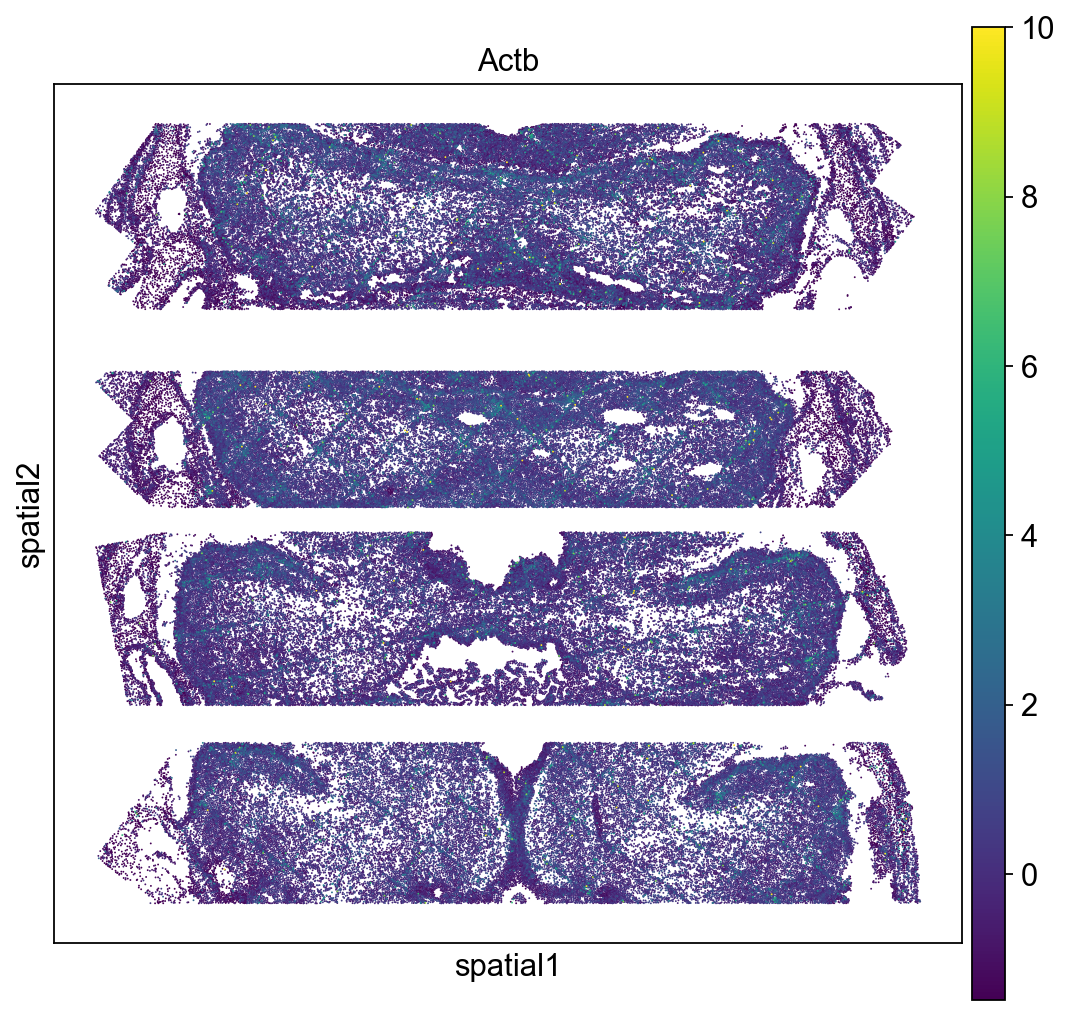

In [277]:
sc.pl.spatial(p0_data, spot_size=75, color = 'Actb')

AnnData object with n_obs × n_vars = 112133 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'


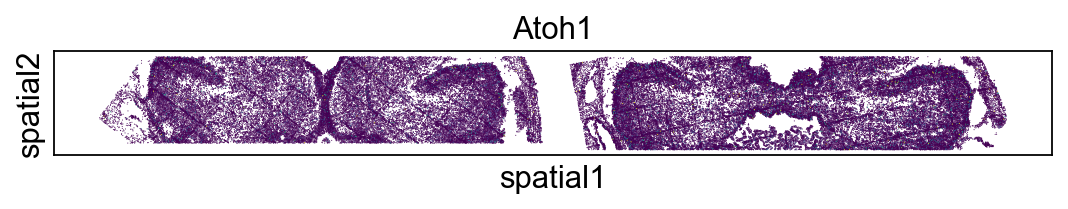

In [280]:
# List of AnnData objects
adatas_list = [p0_1, p0_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 2100 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p0_1_2 = ad.concat(adatas_list, join="outer", label="batch", keys=["p0_1", "p0_2"])

# Verify the combined AnnData object
print(p0_1_2)

sc.pl.spatial(p0_1_2, spot_size = 75, color = "Atoh1", colorbar_loc = None)

AnnData object with n_obs × n_vars = 129754 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'


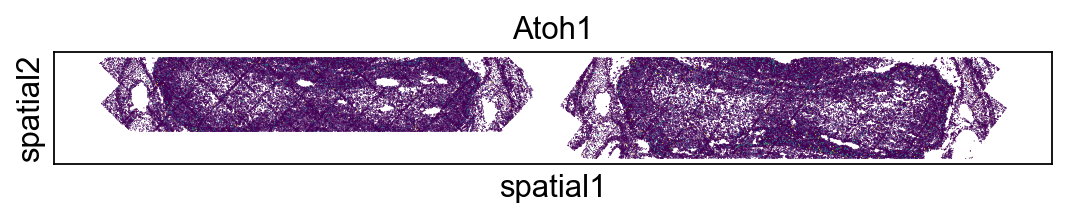

In [281]:
# List of AnnData objects
adatas_list = [p0_3, p0_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 2100 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p0_3_4 = ad.concat(adatas_list, join="outer", label="batch", keys=["p0_3", "p0_4"])

# Verify the combined AnnData object
print(p0_3_4)

sc.pl.spatial(p0_3_4, spot_size = 75, color = "Atoh1", colorbar_loc = None)

AnnData object with n_obs × n_vars = 241887 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'


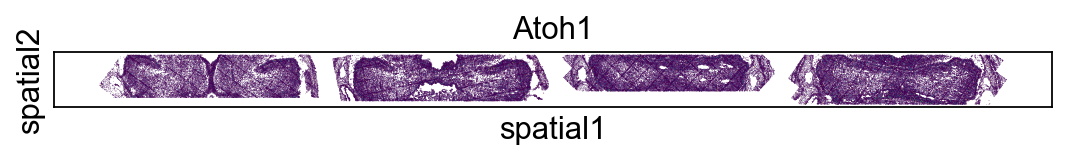

In [282]:
# List of AnnData objects
adatas_list = [p0_1_2, p0_3_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 2100 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p0_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["p0_1", "p0_2", "p0_3", "p0_4"])

# Verify the combined AnnData object
print(p0_combined)

sc.pl.spatial(p0_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [283]:
# Rename an observation variable in the AnnData object
p0_combined.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
p0_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(p0_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'leiden', 'cell_types', 'excitatory',
       'inhibitory'],
      dtype='object')


In [284]:
pd.DataFrame(p0_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,241887.000000,241887.000000
mean,73549.449518,3337.705764
std,39134.736947,2015.449926
min,0.000000,0.000000
25%,41522.884945,1562.263889
50%,76375.203531,3247.424831
75%,111244.970988,5007.121717
max,137416.111125,7499.897695


In [285]:
p0_combined.write("data-for-vitessce/p0_data.h5ad")

In [286]:
# Get all categories
categories = p0_1.obs['finer_cell_types'].cat.categories
len(categories)

43

NameError: name 'p0_1' is not defined

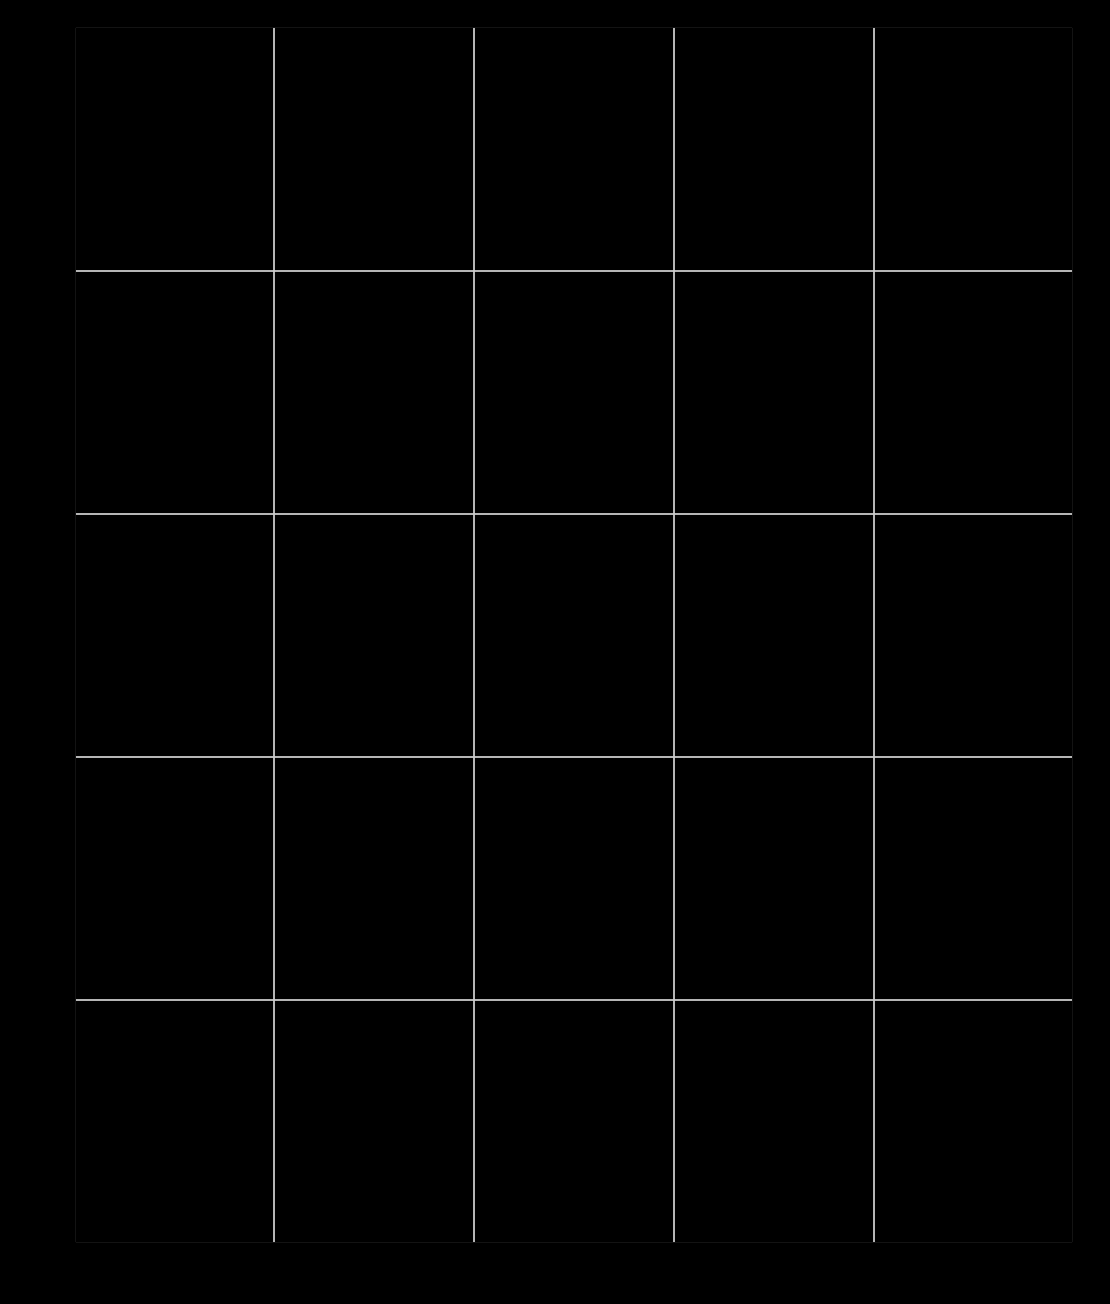

In [109]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    p0_1,
    spot_size=75,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    sort_order=True,
    frameon=False,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/e17_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

# P4

In [3]:
p4_data = ad.read_h5ad("p4_cell_types_spatial_clustering.h5ad")
p4_data

AnnData object with n_obs × n_vars = 159933 × 1740
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

In [4]:
p4_data.obs['library_id'].unique()

['p4_1', 'p4_2', 'p4_3', 'p4_4']
Categories (4, object): ['p4_1', 'p4_2', 'p4_3', 'p4_4']

In [7]:
p4_data.obsm["spatial"][:, 1] = p4_data.obsm["spatial"][:, 1].max() - p4_data.obsm["spatial"][:, 1]

In [8]:
p4_1 = p4_data[p4_data.obs['library_id'] == 'p4_1'].copy()
p4_2 = p4_data[p4_data.obs['library_id'] == 'p4_2'].copy()
p4_3 = p4_data[p4_data.obs['library_id'] == 'p4_3'].copy()
p4_4 = p4_data[p4_data.obs['library_id'] == 'p4_4'].copy()

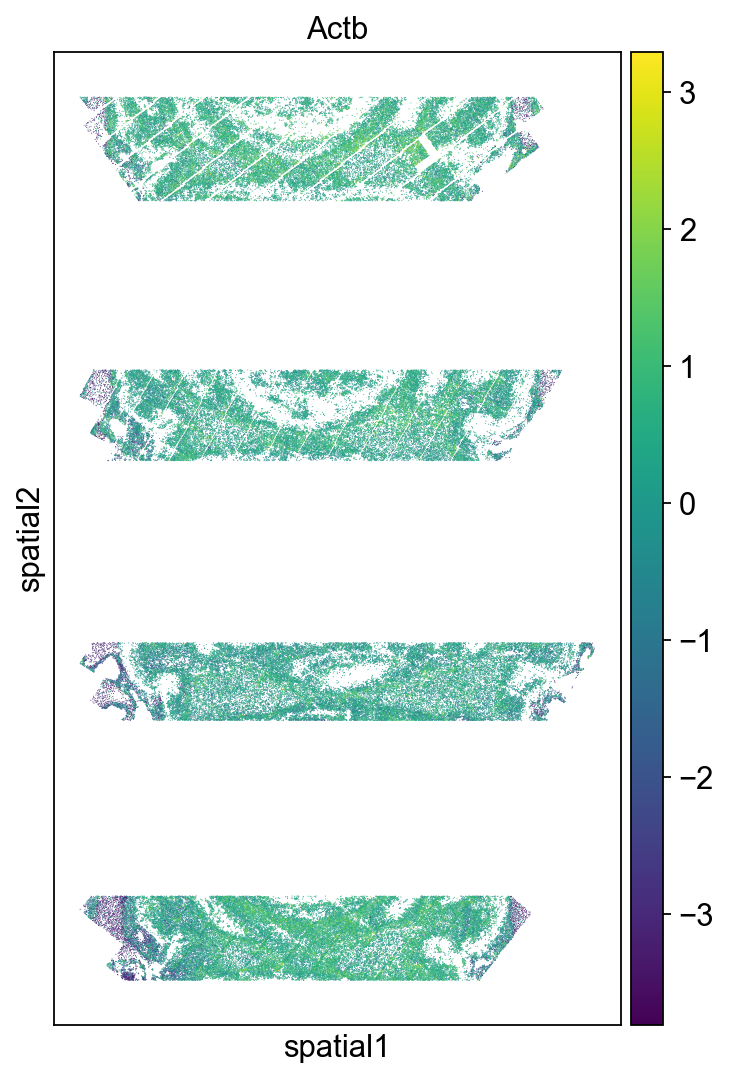

In [9]:
sc.pl.spatial(p4_data, spot_size=75, color = 'Actb')

AnnData object with n_obs × n_vars = 84776 × 1740
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


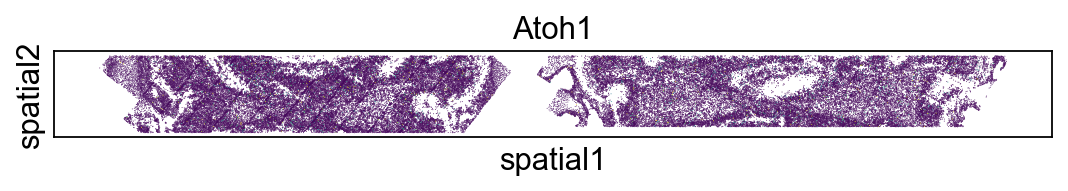

In [10]:
# List of AnnData objects
adatas_list = [p4_1, p4_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 2300 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p4_1_2 = ad.concat(adatas_list, join="outer", label="batch", keys=["p4_1", "p4_2"])

# Verify the combined AnnData object
print(p4_1_2)

sc.pl.spatial(p4_1_2, spot_size = 75, color = "Atoh1", colorbar_loc = None)

AnnData object with n_obs × n_vars = 75157 × 1740
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


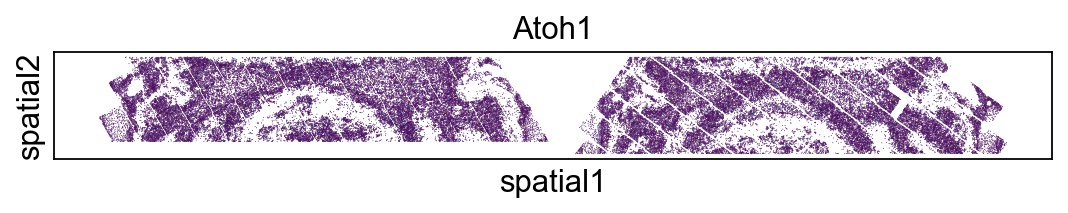

In [14]:
# List of AnnData objects
adatas_list = [p4_3, p4_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 2300 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p4_3_4 = ad.concat(adatas_list, join="outer", label="batch", keys=["p4_3", "p4_4"])

# Verify the combined AnnData object
print(p4_3_4)

sc.pl.spatial(p4_3_4, spot_size = 75, color = "Atoh1", colorbar_loc = None)

AnnData object with n_obs × n_vars = 159933 × 1740
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'excitatory', 'inhibitory'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'


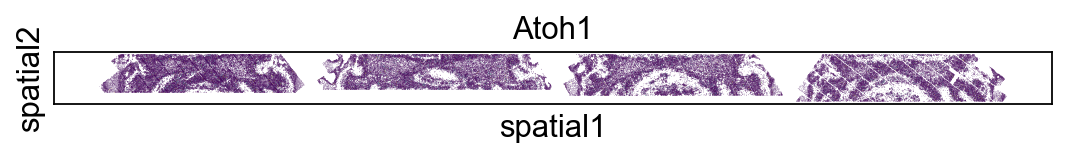

In [39]:
# List of AnnData objects
adatas_list = [p4_1_2, p4_3_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 2100 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p4_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["p4_1", "p4_2", "p4_3", "p4_4"])
# Verify the combined AnnData object
print(p4_combined)

sc.pl.spatial(p4_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [ ]:
# Vertically flip without causing neg values 
p4_combined.obsm["spatial"][:, 1] = p4_combined.obsm["spatial"][:, 1].max() - p4_combined.obsm["spatial"][:, 1]

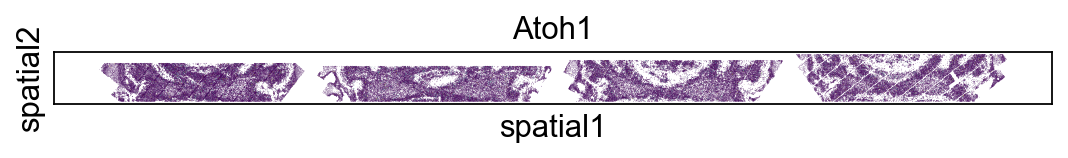

In [41]:
sc.pl.spatial(p4_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [43]:
# Rename an observation variable in the AnnData object
p4_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(p4_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_types',
       'excitatory', 'inhibitory'],
      dtype='object')


In [42]:
pd.DataFrame(p4_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,159933.000000,159933.000000
mean,73277.166360,4505.497063
std,45659.623567,2020.559281
min,0.000000,0.000000
25%,28112.709921,2860.968635
50%,69300.682949,4418.138443
75%,110732.584833,6276.314269
max,153610.768891,7999.481218


In [44]:
p4_combined.write("data-for-vitessce/p4_data.h5ad")

Generate the thumbnail image

In [11]:
# Get all categories
categories = p4_1.obs['finer_cell_types'].cat.categories
len(categories)

20

[]

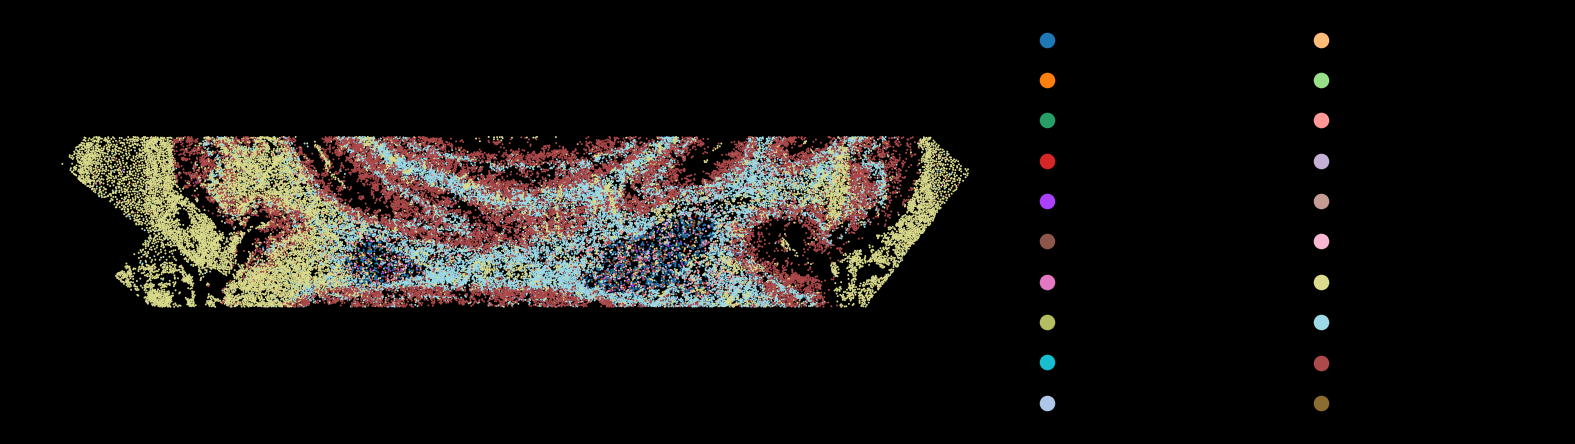

In [13]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    p4_1,
    spot_size=75,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    sort_order=True,
    frameon=False,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
# plt.savefig("figures/p4_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
# plt.close()

# P56

In [111]:
p56_data = ad.read_h5ad("p56_cn_cell_types.h5ad")
p56_data

AnnData object with n_obs × n_vars = 1116 × 1734
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'batch', 'ident', 'library_id', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'X_name', 'batch_colors', 'dendrogram_leiden', 'leiden', 'leiden_colors', 'library_id_colors', 'log1p', 'neighbors', 'pca', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [112]:
p56_data.obs['library_id'].unique()

['p4_1', 'p4_2']
Categories (2, object): ['p4_1', 'p4_2']

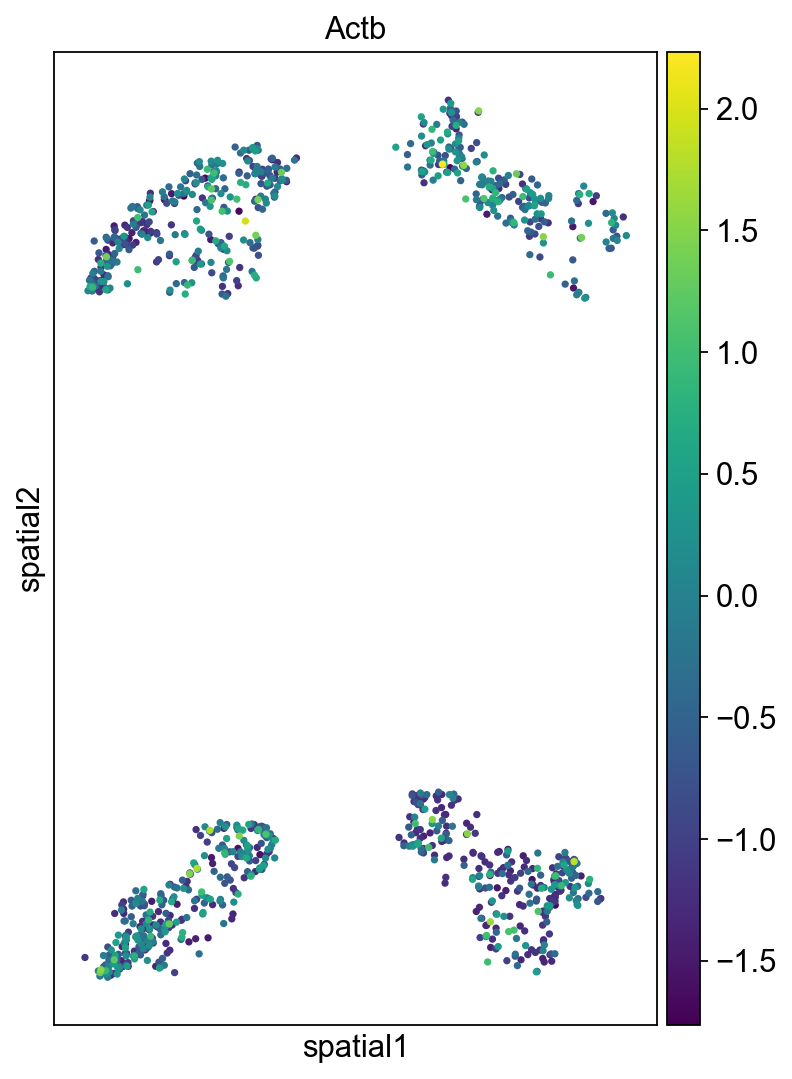

In [113]:
sc.pl.spatial(p56_data, spot_size=440, color = 'Actb')

In [114]:
p56_1 = p56_data[p56_data.obs['library_id'] == 'p4_1'].copy()
p56_2 = p56_data[p56_data.obs['library_id'] == 'p4_2'].copy()

In [115]:
pd.DataFrame(p56_data.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,1116.000000,1116.000000
mean,22966.993513,38901.027957
std,10036.796812,20736.776253
min,8536.229000,11013.460313
25%,13638.370112,17221.694427
50%,19195.597014,53488.914546
75%,32806.205761,58711.005090
max,41156.352273,63863.695250


AnnData object with n_obs × n_vars = 1116 × 1734
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'batch', 'ident', 'library_id', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'


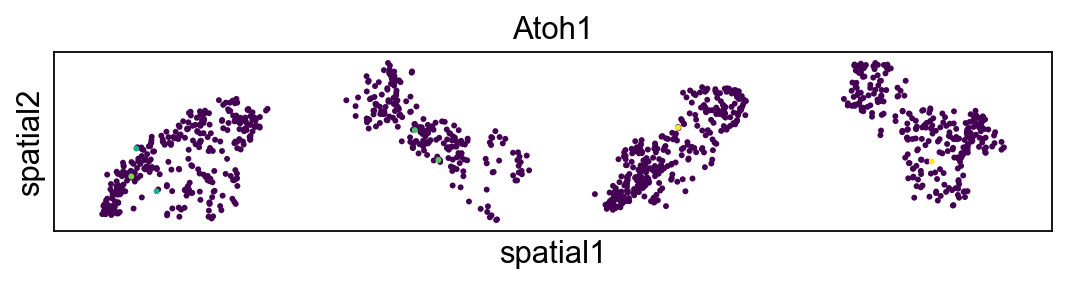

In [116]:
# List of AnnData objects
adatas_list = [p56_1, p56_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 5000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
p56_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["p56_1", "p56_2"])

# Verify the combined AnnData object
print(p56_combined)

sc.pl.spatial(p56_combined, spot_size = 450, color = "Atoh1", colorbar_loc = None)

In [117]:
p56_combined.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'batch', 'ident',
       'library_id', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden',
       'cell_types', 'finer_cell_types'],
      dtype='object')

In [118]:
# Rename an observation variable in the AnnData object
p56_combined.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
p56_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(p56_combined.obs.columns)

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'batch', 'ident',
       'library_id', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden',
       'broad_cell_types', 'cell_types'],
      dtype='object')


In [119]:
p56_combined.write("data-for-vitessce/p56_data.h5ad")

In [122]:
# Set up figure with black background
fig, ax = plt.subplots(figsize=(8, 10), facecolor='black')  # figure background black
ax.set_facecolor('black')  # axes background black

# Plot spatial expression
sc.pl.spatial(
    p56_1,
    spot_size=300,
    color='finer_cell_types',
    colorbar_loc=None,
    ax=ax,  
    sort_order=True,
    frameon=False,  
    show=False  # important to prevent immediate display
    #palette='cubehelix'
)

# Optional: remove axes ticks/labels for cleaner image
ax.set_xticks([])
ax.set_yticks([])

# Save as high-res PNG
plt.savefig("figures/p56_finer_cell_types.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.close()

In [175]:
# Get all categories
categories = p56_1.obs['finer_cell_types'].cat.categories
len(categories)

9